In [48]:
excel_file = "catan_data.xlsx"

import numpy as np
import pandas as pd
import sklearn
import math
import matplotlib as mpl
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# Einlesen und aufbereiten

# Read data and fix column names.
cols = list(pd.read_excel(excel_file).iloc[0, :])
data = pd.read_excel(excel_file).iloc[1:, :]
data.columns = cols

data["score"] = pd.to_numeric(data["score"], errors = "coerce")
    
# Create additional columns.
data["game_id"] = data["season"] * 100 + data["game"]
data["month"] = pd.to_datetime(data["Session"]).dt.month
    
# Split 'geoloc' into 'latitude' and 'longitude'
data[['latitude', 'longitude']] = data['geoloc'].str.split(', ', expand=True)
data['latitude'] = pd.to_numeric(data['latitude'], errors='coerce')
data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')
    
    # Generate additional information columns.
resources = []
for colname in [col for col in data if "t_sum" in col]:
    resources.append(colname[6:])  # extract resource name
for resource in resources:
    # Generate total production values (using min_count=1 so that groups with all NaN return NaN).
    data[f"t_sum_{resource}"] = data.groupby(["season", "game"])[f"p_sum_{resource}"].transform(
        lambda x: x.sum(min_count=1)
    )
        
    # Ensure the columns are numeric.
    data[f"p_sum_{resource}"] = pd.to_numeric(data[f"p_sum_{resource}"], errors="coerce")
    data[f"t_sum_{resource}"] = pd.to_numeric(data[f"t_sum_{resource}"], errors="coerce")
        
    # Generate share of production values safely.
    data[f"share_{resource}"] = np.nan  # default to NaN
    mask = data[f"t_sum_{resource}"] != 0
    data.loc[mask, f"share_{resource}"] = (
        data.loc[mask, f"p_sum_{resource}"] / data.loc[mask, f"t_sum_{resource}"]
    )

# "onehot" create new desert cols
for val in data["desert"].unique():
    if pd.isna(val):
        continue
    else:    
        data["desert_"+val] = (data["desert"] == val).astype(int)

# "onehot" create new position cols
for val in data["position"].unique():
    if pd.isna(val):
        continue
    else:    
        data["position_"+val] = (data["position"] == val).astype(int)   

# "onehot" create new player cols
for val in data["player"].unique():
    if pd.isna(val):
        continue
    else:    
        data["player_"+val] = (data["player"] == val).astype(int)   

# std berechnen
data["std_resources"] = data[[col for col in data if "p_sum" in col]].std(axis = 1)        
    
    
# Generate points column.
data["points"] = data["place"].map({1: 2, 2: 1, 3: 0})
    
# Sort by game_id to ensure cumulative sums are in order.
data = data.sort_values("game_id")
    
# Compute cumulative points (overall and year-to-date) in a vectorized manner.
data["points_cum"] = data.groupby("player")["points"].cumsum()
data["points_cum_ytd"] = data.groupby(["season", "player"])["points"].cumsum()



#produktion: split in rohstoff und handelswaren
data["sum_resources"] = data[['p_sum_wood','p_sum_clay','p_sum_sheep',
                          'p_sum_grain','p_sum_ore',]].apply("sum",axis = 1)
data["sum_tradegoods"] = data[["p_sum_paper","p_sum_coin","p_sum_fabric"]].apply("sum",axis = 1)

 

nn_cols = [col for col in data 
 if "p_sum" in col
 or "share_" in col
 or "port_" in col
 or "desert_" in col
 #or "player_" in col
 or ("sum_" in col and col not in [col for col in data if "t_sum" in col])
 or "std_" in col
] + ["score", "special","place"]

C:\Users\maxfu\envs\ml_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\maxfu\envs\ml_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [55]:
feature_cols = [col for col in nn_cols if col not in ["score","special","place"]]
X = data[feature_cols]
y = data["score"]

X = X.dropna()
y = y[X.index]

# split X_train further into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


# standardize (fit only on train, apply to both)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.transform(X_test)

Epoch 10: Train Loss = 87.2293 | Val Loss = 79.8019
Epoch 20: Train Loss = 70.5542 | Val Loss = 63.8330
Epoch 30: Train Loss = 53.7326 | Val Loss = 47.7237
Epoch 40: Train Loss = 36.8142 | Val Loss = 31.7057
Epoch 50: Train Loss = 21.7181 | Val Loss = 17.7952
Epoch 60: Train Loss = 11.5047 | Val Loss = 8.9180
Epoch 70: Train Loss = 7.6123 | Val Loss = 6.1281


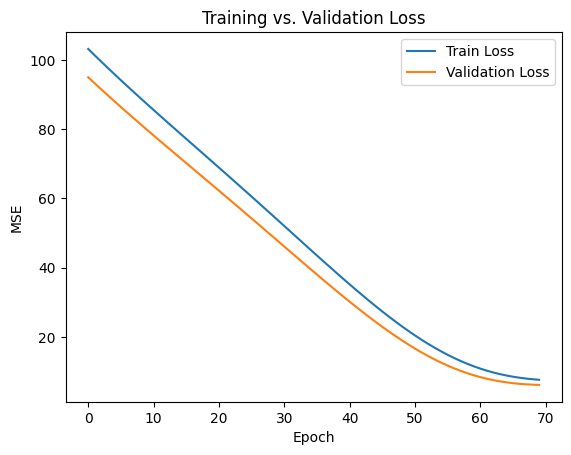

Test MSE: 16.7068


In [56]:
# convert to tensors
X_tr_t  = torch.tensor(X_train,        dtype=torch.float32)
y_tr_t  = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val,       dtype=torch.float32)
y_val_t = torch.tensor(y_val.values,dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test,     dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# define model
model = nn.Sequential(
    nn.Linear(X_tr_t.shape[1], 64),
    nn.Softplus(),
    nn.Linear(64, 32),
    nn.Softplus(),
    nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# tracking lists
train_losses = []
val_losses   = []

for epoch in range(70):
    # training
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)
        val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}")

# plot
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Training vs. Validation Loss")
plt.show()

# final test evaluation
model.eval()
with torch.no_grad():
    test_loss = loss_fn(model(X_test_t), y_test_t)
    print(f"Test MSE: {test_loss.item():.4f}")

In [66]:
# convert to numeric, coerce errors to NaN (what sk-learn did before with train-test-split)
X_clean = X.apply(pd.to_numeric, errors='coerce')
y_clean = y.apply(pd.to_numeric,errors = "coerce")

# use all data this time
X_full = torch.tensor(X_clean.values, dtype=torch.float32)  # your full feature matrix
y_full = torch.tensor(y_clean.values, dtype=torch.float32).unsqueeze(1)

# define model
model_final = nn.Sequential(
    nn.Linear(X_full.shape[1], 64),
    nn.Softplus(),
    nn.Linear(64, 32),
    nn.Softplus(),
    nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model_final.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(70):  # or however many epochs worked well before
    model_final.train()
    optimizer.zero_grad()
    pred = model_final(X_full)
    loss = loss_fn(pred, y_full)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")


Epoch 10: Loss = 59.0901
Epoch 20: Loss = 21.9423
Epoch 30: Loss = 11.6400
Epoch 40: Loss = 11.0828
Epoch 50: Loss = 10.1848
Epoch 60: Loss = 9.6880
Epoch 70: Loss = 9.4569
